In [1]:
import cogent3
from cogent3.maths.matrix_exponential_integration import expected_number_subs
import matplotlib.pyplot as plt
import seaborn as sns
import paths
import pandas as pd
import numpy as np


import pickle

import re
import trinuc_models as trinucs # this module must be in the same directory as this notebook

In [2]:
#function to parse the alignment lenght

def parse_alignment_length(s: str, fmt: str = "{:.6e}") -> str:
    """
    Parse strings like "alignment length: X" and return X formatted in scientific notation.

    Parameters
    - s: input string containing a token like "alignment length: 12345"
    - fmt: a format string compatible with float.format, default "{:.6e}" (6 decimals in exp notation)

    Returns
    - str: the parsed number formatted according to `fmt` (scientific notation by default)

    Raises ValueError if the token is not found.
    """
    m = re.search(r'alignment\s*length\s*:\s*([0-9]+(?:\.[0-9]+)?)', s, re.I)
    if not m:
        raise ValueError(f"Can't parse alignment length from: {s!r}")
    token = m.group(1)
    # normalize to float for consistent formatting
    value = float(token)
    return fmt.format(value)

In [4]:
# Creates a trinucleotide alphabet
aln = cogent3.get_dataset("primate-brca1")
alphabet_trinucs = aln.moltype.alphabet.get_kmer_alphabet(3)

## Intergenic Ancestral Repeats (IGAR)

In [4]:
region = "intergenicAR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_IGAR=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

IGAR_motif_probs = result_IGAR.lf.get_param_value("mprobs")
humanQ_IGAR = result_IGAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_IGAR = expected_number_subs(IGAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS IGAR: ")
print(humanENS_IGAR)

result_IGAR.lf

alignment lenght  2.329884e+06
Human ENS IGAR: 
0.023131180641535937


GT_CpG_ss
log-likelihood = -3782456.8481
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.02              12.03    0.96    3.75    0.81
Chimpanzee    root        0.02              12.31    1.07    3.49    0.87
Orangutan     root        0.10               9.97    0.99    4.94    0.75
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
1.32    1.50    4.93    4.95    1.40    1.32    0.69    3.65
1.21    1.44    4.88    4.84    1.54    1.22    0.76    3.52
1.26    1.37    5.03    4.97    1.38    1.30    0.73    4.88
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.03    0.01    0.02    0.02    0.02    0.01    0.00    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.02    0.02    0.01    0.01    0.02    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.02    0.00    0.02    0.00    0.00    0.00    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.02    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.02    0.03
----------------------------

## CDS

In [5]:
region = "cds/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_cds=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

cds_motif_probs = result_cds.lf.get_param_value("mprobs")
humanQ_cds = result_cds.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_cds = expected_number_subs(cds_motif_probs, humanQ_cds, t=1.0)

print("Human ENS cds: ")
print(humanENS_cds)

#calculate cds if using IGARQ ENS
mprobs = result_cds.lf.get_motif_probs().to_dict()
# get codon freqs and normalize for inclusion of stop codons at 1e-12
mle_freqs = {alphabet_trinuc: mprobs.get(alphabet_trinuc, 1e-12) / (1+3e-12) for alphabet_trinuc in alphabet_trinucs}
mle_freqs = np.array(list(mle_freqs.values()))

humanENS_cds_IGARQ = expected_number_subs(mle_freqs, humanQ_IGAR, t=1.0)

print("Human ENS cds with IGAR Q: ")
print(humanENS_cds_IGARQ)

result_cds.lf

alignment lenght  5.362650e+05
Human ENS cds: 
0.012242264861280187
Human ENS cds with IGAR Q: 
0.029047441097459485


GNC_CpG_ss
log-likelihood = -792069.7226
number of free parameters = 42
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Chimpanzee    root        0.02               3.65    1.26    2.04    1.01
Human         root        0.01               4.16    1.29    4.68    0.76
Orangutan     root        0.05               4.27    1.07    4.07    0.52
-------------------------------------------------------------------------

continued: 
=====================================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C    omega
---------------------------------------------------------------------
0.91    1.25    2.18    1.88    1.72    1.14    0.78    2.07     0.48
1.39    1.67    5.33    4.37    1.41    1.35    0.80    3.17     0.33
0.70    1.19    2.64    2.29    1.16    0.76    0.64    4.38     0.24
---------------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.01    0.02    0.04    0.01    0.01    0.02    0.01    0.01    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.01    0.01    0.00    0.02    0.02    0.01    0.01    0.02    0.04    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.01    0.03    0.01    0.02    0.01    0.02    0.02    0.00    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.05    0.01    0.02    0.03    0.05    0.02    0.01    0.04    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAC     TAT
----------------------------------------------------------------------------
0.01    0.03    0.02    0.01    0.00    0.02    0.03    0.01    0.02    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TCA     TCC     TCG     TCT     TGC     TGG     TGT     TTA     TTC     TTG
----------------------------------------------------------------------------
0.01    0.02    0.01    0.01    0.01    0.01    0.01    0.00    0.02    0.01
----------------------------------------------------------------------------

continued: 
====
 TTT
----
0.01
----

## Introns (nonUTR)

In [6]:
region = "introns_nonUTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_introns=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_introns.lf.get_param_value("mprobs")
humanQ_introns = result_introns.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_introns = expected_number_subs(intron_motif_probs, humanQ_introns, t=1.0)
#This is the ENS of introns if selection was the same as on IGAR. Instead of using the introns Q matrix humanQ_introns, I use the IGAR Q humanQ_IGAR
humanENS_introns_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS introns: ")
print(humanENS_introns)
print("Human ENS introns with IGAR Q: ")
print(humanENS_introns_IGARQ)

result_introns.lf

alignment lenght  6.910554e+06
Human ENS introns: 
0.017720283855225585
Human ENS introns with IGAR Q: 
0.02358158354910298


GT_CpG_ss
log-likelihood = -10893372.3348
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Chimpanzee    root        0.02              10.42    0.97    3.38    0.58
Orangutan     root        0.08               9.04    0.99    4.98    0.59
Human         root        0.02              10.53    1.03    3.99    0.61
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.97    1.46    4.24    4.38    1.38    0.94    0.55    3.22
1.04    1.48    4.52    4.54    1.47    1.05    0.59    4.98
1.15    1.52    4.91    5.05    1.55    1.20    0.59    3.93
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.01    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.02    0.01    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.02    0.01    0.03    0.00    0.00    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.02    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.02    0.02
----------------------------

## 5' UTR

In [7]:
region = "introns5UTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_5UTR=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_5UTR.lf.get_param_value("mprobs")
humanQ_5UTR = result_5UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_5UTR = expected_number_subs(intron_motif_probs, humanQ_5UTR, t=1.0)
#This is the ENS of 5UTR if selection was the same as on IGAR. Instead of using the 5UTR Q matrix humanQ_5UTR, I use the IGAR Q humanQ_IGAR
humanENS_5UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 5UTR: ")
print(humanENS_5UTR)
print("Human ENS 5UTR with IGAR Q: ")
print(humanENS_5UTR_IGARQ)

result_5UTR.lf

alignment lenght  1.131450e+05
Human ENS 5UTR: 
0.016235219063200218
Human ENS 5UTR with IGAR Q: 
0.026045536062106453


GT_CpG_ss
log-likelihood = -177759.1787
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Chimpanzee    root        0.02               6.09    1.13    4.45    0.87
Orangutan     root        0.08               5.48    1.04    4.48    0.40
Human         root        0.02               4.92    0.90    3.45    0.45
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
1.27    2.49    5.70    5.38    2.36    1.72    0.97    3.83
0.88    1.63    3.83    3.73    1.63    0.86    0.47    4.37
1.34    1.62    4.82    4.94    1.46    0.95    0.42    4.52
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.01    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.01    0.01    0.01    0.02    0.03    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.03    0.01    0.02    0.00    0.01    0.01    0.01    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.03    0.02    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.02    0.01
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.02
----------------------------

## 3' UTR

In [8]:
region = "introns3UTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_3UTR=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_3UTR.lf.get_param_value("mprobs")
humanQ_3UTR = result_3UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_3UTR = expected_number_subs(intron_motif_probs, humanQ_3UTR, t=1.0)
#This is the ENS of 3UTR if selection was the same as on IGAR. Instead of using the 3UTR Q matrix humanQ_3UTR, I use the IGAR Q humanQ_IGAR
humanENS_3UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 3UTR: ")
print(humanENS_3UTR)
print("Human ENS 3UTR with IGAR Q: ")
print(humanENS_3UTR_IGARQ)

result_3UTR.lf

alignment lenght  1.070430e+05
Human ENS 3UTR: 
0.01643634701236411
Human ENS 3UTR with IGAR Q: 
0.02679911382558789


GT_CpG_ss
log-likelihood = -167372.7343
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Chimpanzee    root        0.02               5.66    1.19    5.65    0.58
Orangutan     root        0.08               4.96    1.12    4.66    0.65
Human         root        0.02               5.05    0.95    4.36    0.27
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
1.07    2.69    7.75    6.08    1.64    1.87    0.85    5.35
0.89    1.35    3.87    4.06    1.58    0.85    0.63    4.38
0.92    1.50    4.33    3.89    1.42    0.56    0.35    4.06
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.01    0.02    0.01    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.01    0.01    0.01    0.02    0.03    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.03    0.01    0.03    0.00    0.01    0.01    0.01    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.03    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.03    0.03    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.01    0.02    0.00    0.02    0.02    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.02
----------------------------

## Introns Ancestral Repeats (IntronAR)

In [9]:
region = "intronsAR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_intronsAR=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intronsAR_motif_probs = result_intronsAR.lf.get_param_value("mprobs")
humanQ_intronsAR = result_intronsAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_intronsAR = expected_number_subs(intronsAR_motif_probs, humanQ_intronsAR, t=1.0)
#This is the ENS of intronsAR if selection was the same as on IGAR. Instead of using the intronsAR Q matrix humanQ_intronsAR, I use the IGAR Q humanQ_IGAR
humanENS_intronsAR_IGARQ = expected_number_subs(intronsAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS intronsAR: ")
print(humanENS_intronsAR)
print("Human ENS intronsAR with IGAR Q: ")
print(humanENS_intronsAR_IGARQ)

#print("Motif probs: ")
#print(intronsAR_motif_probs)

result_intronsAR.lf

alignment lenght  6.063825e+06
Human ENS intronsAR: 
0.019950886753522332
Human ENS intronsAR with IGAR Q: 
0.02353205791101795


GT_CpG_ss
log-likelihood = -9720969.1495
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.02              12.27    0.98    3.70    0.68
Chimpanzee    root        0.02              11.93    1.03    3.47    0.82
Orangutan     root        0.10               9.91    0.99    5.20    0.69
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
1.17    1.47    5.09    5.22    1.38    1.23    0.67    3.60
1.17    1.45    5.13    5.17    1.37    1.14    0.81    3.41
1.13    1.41    4.85    4.95    1.37    1.09    0.74    5.05
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.03    0.01    0.02    0.02    0.02    0.01    0.00    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.02    0.02    0.01    0.01    0.02    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.02    0.00    0.02    0.00    0.00    0.00    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.01    0.01    0.02    0.01    0.02    0.02    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.02    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.01    0.02    0.03
----------------------------

## Intergenic distal (5kb distal from transcript)

In [10]:
region = "distalIG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_distalIG=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

distalIG_motif_probs = result_distalIG.lf.get_param_value("mprobs")
humanQ_distalIG = result_distalIG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_distalIG = expected_number_subs(distalIG_motif_probs, humanQ_distalIG, t=1.0)
humanENS_distalIG_IGARQ = expected_number_subs(distalIG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS distalIG: ")
print(humanENS_distalIG)
print("Human ENS distalIG with IGAR Q: ")
print(humanENS_distalIG_IGARQ)

result_distalIG.lf

alignment lenght  9.479580e+05
Human ENS distalIG: 
0.023729633791369803
Human ENS distalIG with IGAR Q: 
0.02357595826452024


GT_CpG_ss
log-likelihood = -1531513.3453
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.02              11.08    1.06    4.32    0.69
Chimpanzee    root        0.02              11.78    1.07    3.57    0.70
Orangutan     root        0.10              10.32    1.08    4.86    0.66
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
1.28    1.59    4.95    5.20    1.53    1.31    0.63    3.76
1.18    1.58    4.52    4.32    1.44    1.20    0.69    3.66
1.17    1.43    4.65    4.67    1.51    1.16    0.64    4.96
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.02    0.02    0.01    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.02    0.01    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.03    0.03    0.01    0.03    0.00    0.00    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.02    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.02    0.02
----------------------------

## Intergenic proximal 5' (5kb proximal from transcript start)

In [11]:
region = "proximal5IG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal5IG=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal5IG_motif_probs = result_proximal5IG.lf.get_param_value("mprobs")
humanQ_proximal5IG = result_proximal5IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal5IG = expected_number_subs(proximal5IG_motif_probs, humanQ_proximal5IG, t=1.0)
humanENS_proximal5IG_IGARQ = expected_number_subs(proximal5IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal5IG: ")
print(humanENS_proximal5IG)
print("Human ENS proximal5IG with IGAR Q: ")
print(humanENS_proximal5IG_IGARQ)

result_proximal5IG.lf

alignment lenght  4.925850e+05
Human ENS proximal5IG: 
0.02114595432992339
Human ENS proximal5IG with IGAR Q: 
0.024550607114038912


GT_CpG_ss
log-likelihood = -786584.5684
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.02               8.67    1.03    3.60    0.65
Chimpanzee    root        0.02              10.15    0.93    3.59    0.63
Orangutan     root        0.10               8.25    0.91    4.55    0.58
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
1.21    1.62    4.23    4.57    1.27    1.16    0.72    3.82
1.14    1.43    4.01    4.24    1.74    1.03    0.68    3.34
0.93    1.35    3.82    3.87    1.33    0.91    0.55    4.48
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.01    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.01    0.01    0.01    0.02    0.03    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.03    0.03    0.01    0.03    0.00    0.01    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.03    0.02    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.02
----------------------------

## Intergenic proximal 3' (5kb proximal from transcript end)

In [12]:
region = "proximal3IG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/trinucleotide_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal3IG=pickle.load(infile)

file_in = folder_in + "trinucleotide_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal3IG_motif_probs = result_proximal3IG.lf.get_param_value("mprobs")
humanQ_proximal3IG = result_proximal3IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal3IG = expected_number_subs(proximal3IG_motif_probs, humanQ_proximal3IG, t=1.0)
humanENS_proximal3IG_IGARQ = expected_number_subs(proximal3IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal3IG: ")
print(humanENS_proximal3IG)
print("Human ENS proximal3IG with IGAR Q: ")
print(humanENS_proximal3IG_IGARQ)

result_proximal3IG.lf

alignment lenght  4.908210e+05
Human ENS proximal3IG: 
0.02092254772281282
Human ENS proximal3IG with IGAR Q: 
0.024662847939756347


GT_CpG_ss
log-likelihood = -784553.6963
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.02               8.02    0.79    2.98    0.62
Chimpanzee    root        0.02               8.94    1.20    4.30    1.15
Orangutan     root        0.10               8.11    0.86    4.11    0.53
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.91    0.99    3.49    3.44    1.10    0.91    0.47    3.26
1.29    1.43    5.36    5.13    2.44    0.00    0.70    3.93
0.85    1.18    3.37    3.41    1.17    0.84    0.51    4.13
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.02    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.01    0.01    0.01    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.03    0.03    0.01    0.03    0.00    0.01    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.03    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.02
----------------------------

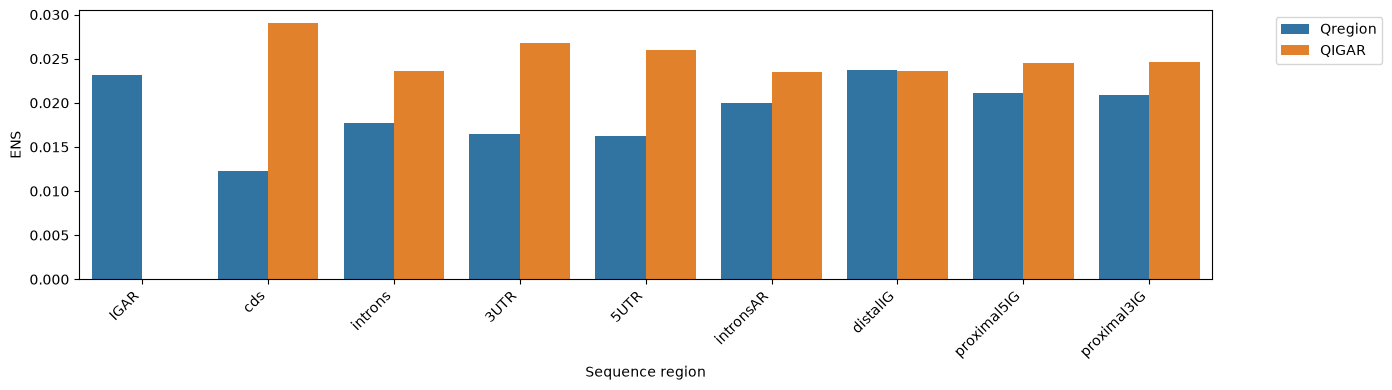

In [13]:
ENS_data = pd.DataFrame([
    ['IGAR', 'Qregion', humanENS_IGAR],
    ['cds', 'Qregion', humanENS_cds],
    ['introns', 'Qregion', humanENS_introns],
    ['3UTR', 'Qregion', humanENS_3UTR],
    ['5UTR', 'Qregion', humanENS_5UTR],
    ['intronsAR', 'Qregion', humanENS_intronsAR],
    ['distalIG', 'Qregion', humanENS_distalIG],
    ['proximal5IG', 'Qregion', humanENS_proximal5IG],
    ['proximal3IG', 'Qregion', humanENS_proximal3IG],
    ['cds', 'QIGAR', humanENS_cds_IGARQ],
    ['introns', 'QIGAR', humanENS_introns_IGARQ],
    ['3UTR', 'QIGAR', humanENS_3UTR_IGARQ],
    ['5UTR', 'QIGAR', humanENS_5UTR_IGARQ],
    ['intronsAR', 'QIGAR', humanENS_intronsAR_IGARQ],
    ['distalIG', 'QIGAR', humanENS_distalIG_IGARQ],
    ['proximal5IG', 'QIGAR', humanENS_proximal5IG_IGARQ],
    ['proximal3IG', 'QIGAR', humanENS_proximal3IG_IGARQ]
    ],
    columns = ['Sequence region', 'Q type', 'ENS'])

plt.figure(figsize=(14, 4))
ax = sns.barplot(
    data=ENS_data,
    x='Sequence region',
    y='ENS',
    hue='Q type'
)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

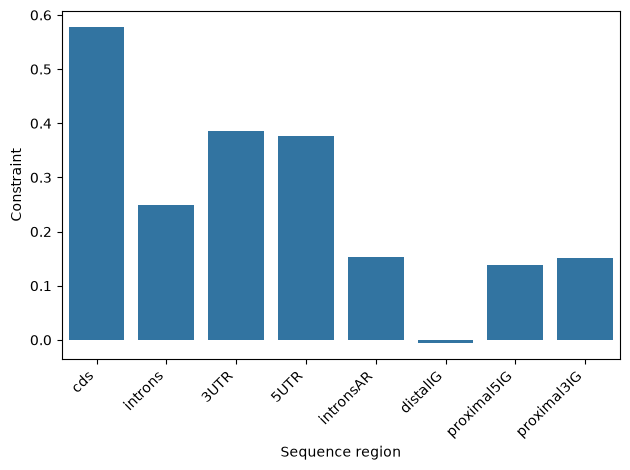

In [14]:
def calculate_constraint(ENS, ENSneutral):
    return (ENSneutral - ENS)/ENSneutral 

Constraint_data = pd.DataFrame([
    ['cds', calculate_constraint(humanENS_cds, humanENS_cds_IGARQ)],
    ['introns', calculate_constraint(humanENS_introns, humanENS_introns_IGARQ)],
    ['3UTR', calculate_constraint(humanENS_3UTR, humanENS_3UTR_IGARQ)],
    ['5UTR', calculate_constraint(humanENS_5UTR, humanENS_5UTR_IGARQ)],
    ['intronsAR', calculate_constraint(humanENS_intronsAR, humanENS_intronsAR_IGARQ)],
    ['distalIG', calculate_constraint(humanENS_distalIG, humanENS_distalIG_IGARQ)],
    ['proximal5IG', calculate_constraint(humanENS_proximal5IG, humanENS_proximal5IG_IGARQ)],
    ['proximal3IG', calculate_constraint(humanENS_proximal3IG, humanENS_proximal3IG_IGARQ)],
    ],
    columns = ['Sequence region', 'Constraint'])

ax = sns.barplot(
    data=Constraint_data,
    x='Sequence region',
    y='Constraint'
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
#Constraint_data.to_csv("Output_data/Constraint_perregion.csv", index=False)
Constraint_data

,Sequence region,Constraint
0,cds,0.578542
1,introns,0.248554
2,3UTR,0.386683
3,5UTR,0.376660
4,intronsAR,0.152183
5,distalIG,-0.006518
6,proximal5IG,0.138679
7,proximal3IG,0.151657
